**REFUGEE2 OPTIC CUP SEGMENTATION**

**Cell 1: Import Libraries**

In [1]:
!pip install pvbm --quiet
!pip install opencv-python-headless --quiet

import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from PVBM.DiscSegmenter import DiscSegmenter
from PIL import Image

# Initialize PVBM segmenter
segmenter = DiscSegmenter()

# Set paths
INPUT_PATH = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2'
OUTPUT_PATH = '/kaggle/working/REFUGE2_Cropped_OD'

print("PVBM Initialized Successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 86.0 MB/s eta 0:00:00:00:01:01
Model path: /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx


Downloading...
From (original): https://drive.google.com/uc?id=116EEFBn7qr_LpCBb8GBuyzpa_KGp4xPX
From (redirected): https://drive.google.com/uc?id=116EEFBn7qr_LpCBb8GBuyzpa_KGp4xPX&confirm=t&uuid=3211d248-1dac-4db2-989a-481fa4d25503
To: /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx
100%|██████████| 125M/125M [00:03<00:00, 34.5MB/s] 

Model downloaded to /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx
PVBM Initialized Successfully!


**Cell 2: Getting optic disc crop out region or ROI from original full CFI**

In [2]:
'''
Getting optic disc crop out region or ROI from original full CFI
'''

def get_optic_disc(image_path):
    """Get optic disc mask and center coordinates using PVBM"""
    try:
        optic_disc_pil = segmenter.segment(image_path=image_path)
        optic_disc = np.array(optic_disc_pil)
        center, radius, roi, zones_ABC = segmenter.post_processing(
            segmentation=optic_disc_pil,
            max_roi_size=600
        )
        return optic_disc, center, radius
    except Exception as e:
        return None, None, None

def getDiscFromOriginalImage(img_cropped, optic_disc_mask):
    masked = cv2.bitwise_and(img_cropped, img_cropped, mask=optic_disc_mask)
    masked = cv2.resize(masked, (256, 256))
    mb, mg, mr = cv2.split(masked)
    masked = cv2.merge((mb, mg, mr))
    return masked

def countingBox(optic_disc, img):
    """Crop image around optic disc based on mask"""
    try:
        optic_disc = np.array(optic_disc)

        if len(optic_disc.shape) == 3:
            optic_disc = cv2.cvtColor(optic_disc, cv2.COLOR_RGB2GRAY)

        _, binary_mask = cv2.threshold(optic_disc, 1, 255, cv2.THRESH_BINARY)

        ys, xs = np.where(binary_mask > 0)
        
        # Check if mask has any white pixels
        if len(ys) == 0 or len(xs) == 0:
            return None, None
        
        # Add padding of 50 pixels with bounds checking
        h, w = binary_mask.shape
        ymin = max(ys.min() - 50, 0)
        ymax = min(ys.max() + 50, h - 1)
        xmin = max(xs.min() - 50, 0)
        xmax = min(xs.max() + 50, w - 1)
        
        # Check if crop region is valid
        if ymin >= ymax or xmin >= xmax:
            return None, None

        resized_img = cv2.resize(img, (binary_mask.shape[1], binary_mask.shape[0]))

        img_cropped = resized_img[ymin:ymax+1, xmin:xmax+1]
        optic_disc_mask = optic_disc[ymin:ymax+1, xmin:xmax+1]
        
        if img_cropped.size == 0 or optic_disc_mask.size == 0:
            return None, None

        return img_cropped, optic_disc_mask
    except Exception as e:
        return None, None

def crop_image_from_gray(img, tol=7):
    if img is None or img.size == 0:
        return np.zeros((256, 256, 3), dtype=np.uint8)
    
    if img.ndim == 2:
        mask = img > tol
        if mask.any():
            return img[np.ix_(mask.any(1), mask.any(0))]
        return img
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        if img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0] == 0:
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def crop_image_from_gray_with_coords(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol

    if not mask.any():
        h,w = img.shape[:2]
        return img, (0,h,0,w)

    rows = mask.any(1)
    cols = mask.any(0)

    ymin = np.where(rows)[0][0]
    ymax = np.where(rows)[0][-1]

    xmin = np.where(cols)[0][0]
    xmax = np.where(cols)[0][-1]

    cropped = img[
        ymin:ymax+1,
        xmin:xmax+1
    ]

    return cropped, (ymin,ymax,xmin,xmax)

def crop_mask_using_pvbm(mask_path, center, radius):
    mask = cv2.imread(mask_path)
    h, w = mask.shape[:2]
    cx, cy = int(center[0]), int(center[1])
    r = int(radius * 1.2)
    r = min(r, 600//2)
    xmin = max(cx-r, 0)
    xmax = min(cx+r, w)
    ymin = max(cy-r, 0)
    ymax = min(cy+r, h)

    cropped_mask = mask[ymin:ymax, xmin:xmax]
    cropped_mask = cv2.resize(cropped_mask,(256,256),interpolation=cv2.INTER_NEAREST)
    gray = cv2.cvtColor(cropped_mask,cv2.COLOR_BGR2GRAY)
    oc_mask = cv2.inRange(gray,0,20)

    return oc_mask    

def crop_optic_disc_from_path(image_path):
    """Complete pipeline: load image, detect disc, crop, return cropped disc"""
    try:
        img = cv2.imread(image_path)
        od_mask, center, radius = get_optic_disc(image_path)
        img_cropped, optic_disc_mask = countingBox(od_mask, img)
        od_mask = getDiscFromOriginalImage(img_cropped, optic_disc_mask)
        od_mask = crop_image_from_gray(od_mask)
        
        return od_mask
    
    except Exception as e:
        return e

def crop_optic_disc_and_mask(image_path, mask_path):
    img = cv2.imread(image_path)
    od_mask, center, radius = get_optic_disc(image_path)
    mask = crop_mask_using_pvbm(mask_path, center, radius)
    img_cropped, optic_disc_mask = countingBox(od_mask,img)
    cropped_image = getDiscFromOriginalImage(img_cropped,optic_disc_mask)
    cropped_image, (ymin,ymax,xmin,xmax) = crop_image_from_gray_with_coords(cropped_image)
    cropped_mask = mask[
        ymin:ymax+1,
        xmin:xmax+1
    ]

    return cropped_image, cropped_mask

**Cell 3: Test on single image**

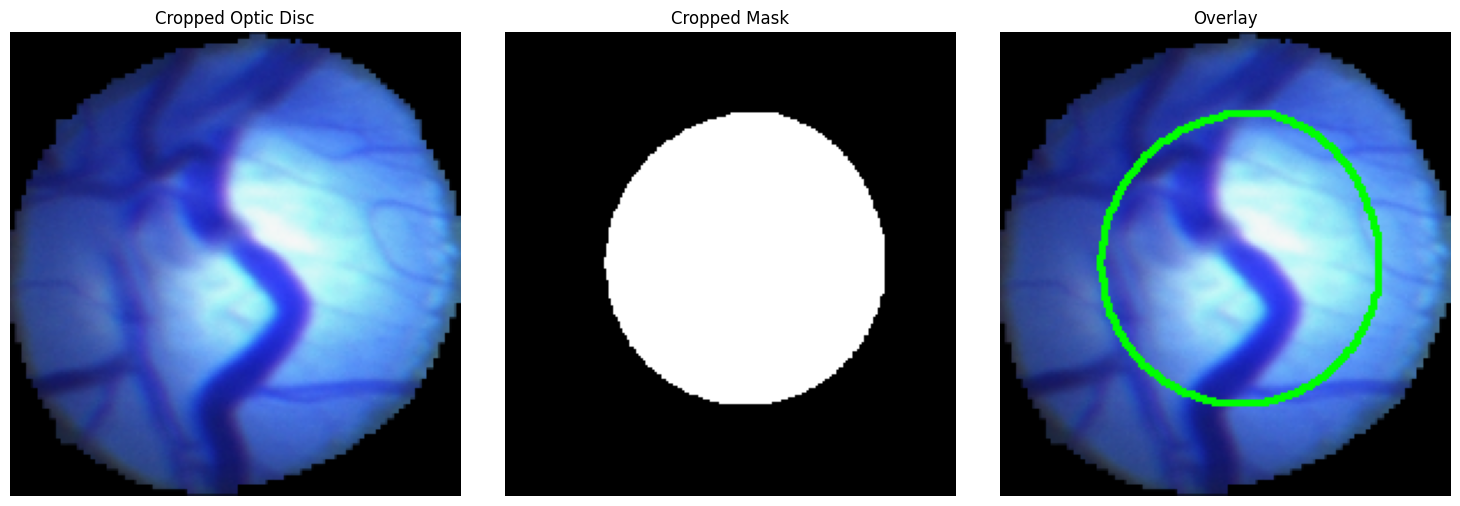

Cropped Image shape: (202, 196, 3)
Cropped Mask shape: (202, 196)
Mask unique values: [  0 255]
Cup area: 12152 pixels
✅ Saved: test_cropped_od.jpg (BGR format for correct colors)


In [3]:
test_image = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2/train/images/g0001.jpg'
test_mask = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2/train/mask/g0001.bmp'

cropped_image, cropped_mask = crop_optic_disc_and_mask(test_image, test_mask)

# Convert RGB to BGR for saving (to preserve colors)
cropped_image_bgr = cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cropped optic disc (RGB for display)
axes[0].imshow(cropped_image)
axes[0].set_title('Cropped Optic Disc')
axes[0].axis('off')

# Cropped mask (optic cup)
axes[1].imshow(cropped_mask, cmap='gray')
axes[1].set_title('Cropped Mask')
axes[1].axis('off')

# Overlay
overlay = cropped_image.copy()
contours, _ = cv2.findContours(cropped_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)
axes[2].imshow(overlay)
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Save with BGR conversion
cv2.imwrite('/kaggle/working/test_cropped_od.jpg', cropped_image_bgr)
cv2.imwrite('/kaggle/working/test_cropped_mask.png', cropped_mask)

print(f"Cropped Image shape: {cropped_image.shape}")
print(f"Cropped Mask shape: {cropped_mask.shape}")
print(f"Mask unique values: {np.unique(cropped_mask)}")
print(f"Cup area: {np.sum(cropped_mask > 0)} pixels")
print(f"✅ Saved: test_cropped_od.jpg (BGR format for correct colors)")

**Cell 4: Batch process on all images**

In [6]:
INPUT_PATH = '/kaggle/input/datasets/victorlemosml/refuge2/REFUGE2'
OUTPUT_PATH = '/kaggle/working/REFUGE2_Cropped_OD'

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

splits = ['train', 'val', 'test']
stats = {}

print("="*60)
print("PROCESSING ALL IMAGES")
print("="*60)

for split in splits:
    images_dir = os.path.join(INPUT_PATH, split, 'images')
    masks_dir = os.path.join(INPUT_PATH, split, 'mask')
    
    if not os.path.exists(images_dir):
        print(f"⚠ Skipping {split}")
        continue
    
    out_images_dir = os.path.join(OUTPUT_PATH, split, 'images')
    out_masks_dir = os.path.join(OUTPUT_PATH, split, 'mask')
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_masks_dir, exist_ok=True)
    
    image_files = [f for f in os.listdir(images_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
    
    print(f"\n📁 {split} - {len(image_files)} images")
    
    success = 0
    for img_file in tqdm(image_files):
        try:
            img_name = Path(img_file).stem
            img_path = os.path.join(images_dir, img_file)
            
            # Find corresponding mask
            mask_file = None
            for ext in ['.bmp', '.png', '.jpg']:
                potential = os.path.join(masks_dir, f"{img_name}{ext}")
                if os.path.exists(potential):
                    mask_file = potential
                    break
            
            if mask_file is None:
                continue
            
            # Use sir's function
            cropped_image, cropped_mask = crop_optic_disc_and_mask(img_path, mask_file)
            
            # NO CONVERSION NEEDED - cropped_image is already in BGR format
            # Save cropped optic disc directly
            output_img_path = os.path.join(out_images_dir, f"{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_image)  # Direct save, no conversion
            
            # Save cropped mask
            output_mask_path = os.path.join(out_masks_dir, f"{img_name}.png")
            cv2.imwrite(output_mask_path, cropped_mask)
            
            success += 1
            
        except Exception as e:
            continue
    
    stats[split] = success
    print(f"  ✅ {split}: {success} images")

# Create ZIP
zip_path = '/kaggle/working/REFUGE2_Processed.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.dirname(OUTPUT_PATH)))

print(f"\n✅ ZIP created: {zip_path}")
print(f"📊 Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

from IPython.display import FileLink, display
display(FileLink(zip_path))

PROCESSING ALL IMAGES

📁 train - 400 images


100%|██████████| 400/400 [23:05<00:00,  3.46s/it]


  ✅ train: 400 images

📁 val - 400 images


100%|██████████| 400/400 [22:43<00:00,  3.41s/it]


  ✅ val: 400 images

📁 test - 400 images


100%|██████████| 400/400 [22:09<00:00,  3.32s/it]


  ✅ test: 400 images

✅ ZIP created: /kaggle/working/REFUGE2_Processed.zip
📊 Size: 13.55 MB


/kaggle/working/REFUGE2_Processed.zip

**DRISHTI GS OPTIC CUP SEGMENTATION**

**Cell 1: Import Libraries**

In [1]:
!pip install pvbm --quiet
!pip install opencv-python-headless --quiet

import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from PVBM.DiscSegmenter import DiscSegmenter
from PIL import Image

# Initialize PVBM segmenter
segmenter = DiscSegmenter()

# Set paths
INPUT_PATH = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation'
OUTPUT_PATH = '/kaggle/working/DRISHTI-GS_Cropped_OD'

print("PVBM Initialized Successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.9 MB/s eta 0:00:00:00:0100:01
Model path: /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx


Downloading...
From (original): https://drive.google.com/uc?id=116EEFBn7qr_LpCBb8GBuyzpa_KGp4xPX
From (redirected): https://drive.google.com/uc?id=116EEFBn7qr_LpCBb8GBuyzpa_KGp4xPX&confirm=t&uuid=2256fbb6-a39f-4bbe-8581-55c031f46dd2
To: /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx
100%|██████████| 125M/125M [00:03<00:00, 32.0MB/s] 

Model downloaded to /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx
PVBM Initialized Successfully!


**Cell 2: Getting optic disc crop out region or ROI from original full CFI**

In [2]:
'''
Getting optic disc crop out region or ROI from original full CFI
'''

def get_optic_disc(image_path):
    """Get optic disc mask and center coordinates using PVBM"""
    try:
        optic_disc_pil = segmenter.segment(image_path=image_path)
        optic_disc = np.array(optic_disc_pil)
        center, radius, roi, zones_ABC = segmenter.post_processing(
            segmentation=optic_disc_pil,
            max_roi_size=600
        )
        return optic_disc, center, radius
    except Exception as e:
        return None, None, None

def getDiscFromOriginalImage(img_cropped, optic_disc_mask):
    masked = cv2.bitwise_and(img_cropped, img_cropped, mask=optic_disc_mask)
    masked = cv2.resize(masked, (256, 256))
    mb, mg, mr = cv2.split(masked)
    masked = cv2.merge((mb, mg, mr))
    return masked

def countingBox(optic_disc, img):
    """Crop image around optic disc based on mask"""
    try:
        optic_disc = np.array(optic_disc)

        if len(optic_disc.shape) == 3:
            optic_disc = cv2.cvtColor(optic_disc, cv2.COLOR_RGB2GRAY)

        _, binary_mask = cv2.threshold(optic_disc, 1, 255, cv2.THRESH_BINARY)

        ys, xs = np.where(binary_mask > 0)
        
        # Check if mask has any white pixels
        if len(ys) == 0 or len(xs) == 0:
            return None, None
        
        # Add padding of 50 pixels with bounds checking
        h, w = binary_mask.shape
        ymin = max(ys.min() - 50, 0)
        ymax = min(ys.max() + 50, h - 1)
        xmin = max(xs.min() - 50, 0)
        xmax = min(xs.max() + 50, w - 1)
        
        # Check if crop region is valid
        if ymin >= ymax or xmin >= xmax:
            return None, None

        resized_img = cv2.resize(img, (binary_mask.shape[1], binary_mask.shape[0]))

        img_cropped = resized_img[ymin:ymax+1, xmin:xmax+1]
        optic_disc_mask = optic_disc[ymin:ymax+1, xmin:xmax+1]
        
        if img_cropped.size == 0 or optic_disc_mask.size == 0:
            return None, None

        return img_cropped, optic_disc_mask
    except Exception as e:
        return None, None

def crop_image_from_gray(img, tol=7):
    if img is None or img.size == 0:
        return np.zeros((256, 256, 3), dtype=np.uint8)
    
    if img.ndim == 2:
        mask = img > tol
        if mask.any():
            return img[np.ix_(mask.any(1), mask.any(0))]
        return img
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        if img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0] == 0:
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def crop_image_from_gray_with_coords(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol

    if not mask.any():
        h,w = img.shape[:2]
        return img, (0,h,0,w)

    rows = mask.any(1)
    cols = mask.any(0)

    ymin = np.where(rows)[0][0]
    ymax = np.where(rows)[0][-1]

    xmin = np.where(cols)[0][0]
    xmax = np.where(cols)[0][-1]

    cropped = img[
        ymin:ymax+1,
        xmin:xmax+1
    ]

    return cropped, (ymin,ymax,xmin,xmax)

def crop_mask_using_pvbm(mask_path, center, radius):
    mask = cv2.imread(mask_path)
    h, w = mask.shape[:2]
    cx, cy = int(center[0]), int(center[1])
    r = int(radius * 1.2)
    r = min(r, 600//2)
    xmin = max(cx-r, 0)
    xmax = min(cx+r, w)
    ymin = max(cy-r, 0)
    ymax = min(cy+r, h)

    cropped_mask = mask[ymin:ymax, xmin:xmax]
    cropped_mask = cv2.resize(cropped_mask,(256,256),interpolation=cv2.INTER_NEAREST)
    gray = cv2.cvtColor(cropped_mask,cv2.COLOR_BGR2GRAY)
    oc_mask = cv2.inRange(gray,0,20)

    return oc_mask    

def crop_optic_disc_from_path(image_path):
    """Complete pipeline: load image, detect disc, crop, return cropped disc"""
    try:
        img = cv2.imread(image_path)
        od_mask, center, radius = get_optic_disc(image_path)
        img_cropped, optic_disc_mask = countingBox(od_mask, img)
        od_mask = getDiscFromOriginalImage(img_cropped, optic_disc_mask)
        od_mask = crop_image_from_gray(od_mask)
        
        return od_mask
    
    except Exception as e:
        return e

def crop_optic_disc_and_mask(image_path, mask_path):
    img = cv2.imread(image_path)
    od_mask, center, radius = get_optic_disc(image_path)
    mask = crop_mask_using_pvbm(mask_path, center, radius)
    img_cropped, optic_disc_mask = countingBox(od_mask,img)
    cropped_image = getDiscFromOriginalImage(img_cropped,optic_disc_mask)
    cropped_image, (ymin,ymax,xmin,xmax) = crop_image_from_gray_with_coords(cropped_image)
    cropped_mask = mask[
        ymin:ymax+1,
        xmin:xmax+1
    ]

    return cropped_image, cropped_mask

**Cell 3: Test on single image**

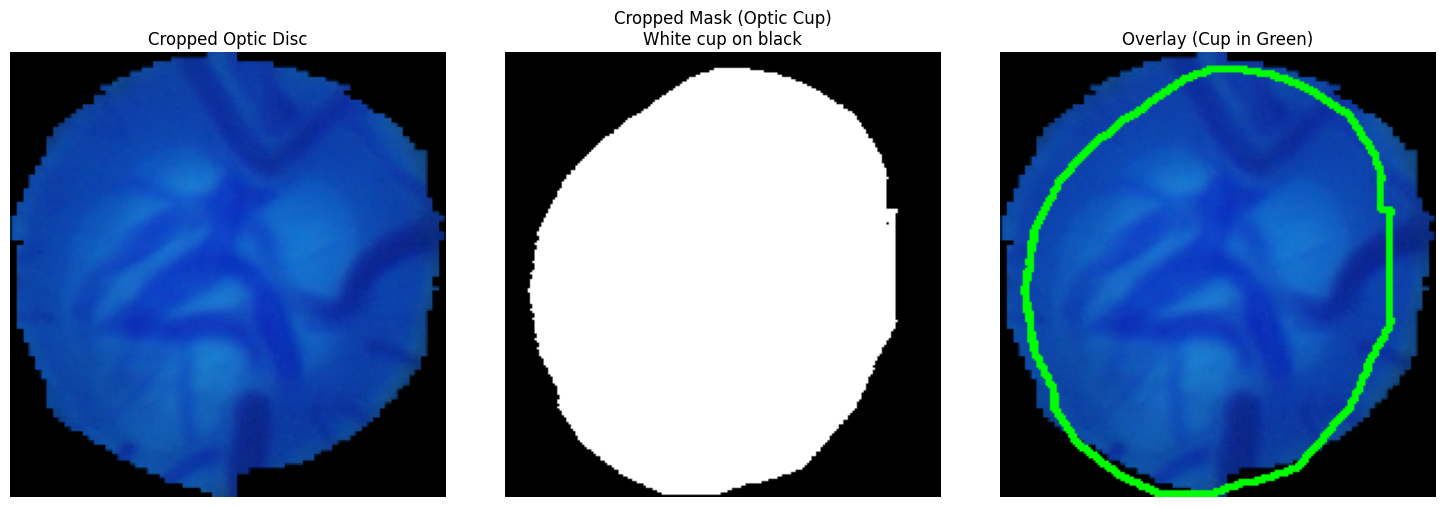

Cropped Image shape: (196, 192, 3)
Cropped Mask shape: (196, 192)
Mask unique values: [  0 255]
Cup area (white pixels): 23616 pixels
✅ Cup is now WHITE, background is BLACK


In [3]:
# Test on Drishti GS image with mask inversion
test_image = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/Test-20211018T060000Z-001/Test/Images/glaucoma/drishtiGS_023.png'
test_mask = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation/Test-20211018T060000Z-001/Test/Test_GT/drishtiGS_023/SoftMap/drishtiGS_023_cupsegSoftmap.png'

cropped_image, cropped_mask = crop_optic_disc_and_mask(test_image, test_mask)

# INVERT THE MASK: Make cup white (255) and background black (0)
cropped_mask = 255 - cropped_mask

# Convert RGB to BGR for saving (to preserve colors)
cropped_image_bgr = cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cropped optic disc (RGB for display)
axes[0].imshow(cropped_image)
axes[0].set_title('Cropped Optic Disc')
axes[0].axis('off')

# Cropped mask (optic cup) - NOW CUP IS WHITE
axes[1].imshow(cropped_mask, cmap='gray')
axes[1].set_title('Cropped Mask (Optic Cup)\nWhite cup on black')
axes[1].axis('off')

# Overlay
overlay = cropped_image.copy()
contours, _ = cv2.findContours(cropped_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)
axes[2].imshow(overlay)
axes[2].set_title('Overlay (Cup in Green)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Save
cv2.imwrite('/kaggle/working/drishti_test_cropped_od.jpg', cropped_image_bgr)
cv2.imwrite('/kaggle/working/drishti_test_cropped_mask.png', cropped_mask)

print(f"Cropped Image shape: {cropped_image.shape}")
print(f"Cropped Mask shape: {cropped_mask.shape}")
print(f"Mask unique values: {np.unique(cropped_mask)}")
print(f"Cup area (white pixels): {np.sum(cropped_mask > 0)} pixels")
print(f"✅ Cup is now WHITE, background is BLACK")

**Cell 4: Batch Processing for all images**

In [7]:
INPUT_PATH = '/kaggle/input/datasets/lokeshsaipureddi/drishtigs-retina-dataset-for-onh-segmentation'
OUTPUT_PATH = '/kaggle/working/DRISHTI_GS_Cropped_OD'

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

# Drishti GS structure
main_folders = ['Training-20211018T055246Z-001', 'Test-20211018T060000Z-001']

stats = {}

print("="*60)
print("PROCESSING ALL DRISHTI GS IMAGES")
print("="*60)

for main_folder in main_folders:
    # Determine if it's Training or Test
    if 'Training' in main_folder:
        sub_folder = 'Training'
        categories = ['GLAUCOMA', 'NORMAL']
        gt_folder_name = 'GT'
        mask_pattern = "{img_name}_cupsegSoftmap.png"
    else:  # Test
        sub_folder = 'Test'
        categories = ['glaucoma', 'normal']
        gt_folder_name = 'Test_GT'
        mask_pattern = "{img_name}_cupsegSoftmap.png"
    
    for category in categories:
        images_dir = os.path.join(INPUT_PATH, main_folder, sub_folder, 'Images', category)
        masks_base = os.path.join(INPUT_PATH, main_folder, sub_folder, gt_folder_name)
        
        if not os.path.exists(images_dir):
            continue
        
        out_images_dir = os.path.join(OUTPUT_PATH, main_folder, category, 'images')
        out_masks_dir = os.path.join(OUTPUT_PATH, main_folder, category, 'mask')
        os.makedirs(out_images_dir, exist_ok=True)
        os.makedirs(out_masks_dir, exist_ok=True)
        
        image_files = [f for f in os.listdir(images_dir) 
                       if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        
        print(f"\n📁 {main_folder}/{category} - {len(image_files)} images")
        
        success = 0
        for img_file in tqdm(image_files):
            try:
                img_name = Path(img_file).stem
                img_path = os.path.join(images_dir, img_file)
                
                # Find corresponding mask
                mask_path = os.path.join(masks_base, img_name, 'SoftMap', mask_pattern.format(img_name=img_name))
                
                if not os.path.exists(mask_path):
                    print(f"  Mask not found: {mask_path}")
                    continue
                
                # Use sir's function
                cropped_image, cropped_mask = crop_optic_disc_and_mask(img_path, mask_path)
                
                # INVERT MASK: Make cup white, background black
                cropped_mask = 255 - cropped_mask
                
                # Save cropped optic disc directly (already in BGR)
                output_img_path = os.path.join(out_images_dir, f"{img_name}.jpg")
                cv2.imwrite(output_img_path, cropped_image)
                
                # Save cropped mask
                output_mask_path = os.path.join(out_masks_dir, f"{img_name}.png")
                cv2.imwrite(output_mask_path, cropped_mask)
                
                success += 1
                
            except Exception as e:
                continue
        
        stats[f"{main_folder}/{category}"] = success
        print(f"  ✅ {success} images")

# Create ZIP
zip_path = '/kaggle/working/DRISHTI_GS_Processed.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.dirname(OUTPUT_PATH)))

print(f"\n✅ ZIP created: {zip_path}")
print(f"📊 Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

from IPython.display import FileLink, display
display(FileLink(zip_path))

PROCESSING ALL DRISHTI GS IMAGES

📁 Training-20211018T055246Z-001/GLAUCOMA - 32 images


100%|██████████| 32/32 [01:53<00:00,  3.54s/it]


  ✅ 32 images

📁 Training-20211018T055246Z-001/NORMAL - 18 images


100%|██████████| 18/18 [01:05<00:00,  3.63s/it]


  ✅ 18 images

📁 Test-20211018T060000Z-001/glaucoma - 38 images


100%|██████████| 38/38 [02:16<00:00,  3.60s/it]


  ✅ 38 images

📁 Test-20211018T060000Z-001/normal - 13 images


100%|██████████| 13/13 [00:45<00:00,  3.52s/it]

  ✅ 13 images

✅ ZIP created: /kaggle/working/DRISHTI_GS_Processed.zip
📊 Size: 1.26 MB


/kaggle/working/DRISHTI_GS_Processed.zip

**CHAKSHU OPTIC CUP SEGMENTATION**

**Cell 1: Import Libraries**

In [2]:
!pip install pvbm --quiet
!pip install opencv-python-headless --quiet

import os
import cv2
import numpy as np
import zipfile
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from PVBM.DiscSegmenter import DiscSegmenter
from PIL import Image

# Initialize PVBM segmenter
segmenter = DiscSegmenter()

# Set paths
INPUT_PATH = '/kaggle/input/datasets/mrunal0501/chakshu/Test'
OUTPUT_PATH = '/kaggle/working/Chakshu_Cropped_OD'

print("PVBM Initialized Successfully!")

Model path: /usr/local/lib/python3.12/dist-packages/PVBM/lunetv2_odc.onnx
Model already exists, skipping download.
PVBM Initialized Successfully!


**Cell 2: Getting optic disc crop out region or ROI from original full CFI**

In [3]:
'''
Getting optic disc crop out region or ROI from original full CFI
'''

def get_optic_disc(image_path):
    """Get optic disc mask and center coordinates using PVBM"""
    try:
        optic_disc_pil = segmenter.segment(image_path=image_path)
        optic_disc = np.array(optic_disc_pil)
        center, radius, roi, zones_ABC = segmenter.post_processing(
            segmentation=optic_disc_pil,
            max_roi_size=600
        )
        return optic_disc, center, radius
    except Exception as e:
        return None, None, None

def getDiscFromOriginalImage(img_cropped, optic_disc_mask):
    masked = cv2.bitwise_and(img_cropped, img_cropped, mask=optic_disc_mask)
    masked = cv2.resize(masked, (256, 256))
    mb, mg, mr = cv2.split(masked)
    masked = cv2.merge((mb, mg, mr))
    return masked

def countingBox(optic_disc, img):
    """Crop image around optic disc based on mask"""
    try:
        optic_disc = np.array(optic_disc)

        if len(optic_disc.shape) == 3:
            optic_disc = cv2.cvtColor(optic_disc, cv2.COLOR_RGB2GRAY)

        _, binary_mask = cv2.threshold(optic_disc, 1, 255, cv2.THRESH_BINARY)

        ys, xs = np.where(binary_mask > 0)
        
        # Check if mask has any white pixels
        if len(ys) == 0 or len(xs) == 0:
            return None, None
        
        # Add padding of 50 pixels with bounds checking
        h, w = binary_mask.shape
        ymin = max(ys.min() - 50, 0)
        ymax = min(ys.max() + 50, h - 1)
        xmin = max(xs.min() - 50, 0)
        xmax = min(xs.max() + 50, w - 1)
        
        # Check if crop region is valid
        if ymin >= ymax or xmin >= xmax:
            return None, None

        resized_img = cv2.resize(img, (binary_mask.shape[1], binary_mask.shape[0]))

        img_cropped = resized_img[ymin:ymax+1, xmin:xmax+1]
        optic_disc_mask = optic_disc[ymin:ymax+1, xmin:xmax+1]
        
        if img_cropped.size == 0 or optic_disc_mask.size == 0:
            return None, None

        return img_cropped, optic_disc_mask
    except Exception as e:
        return None, None

def crop_image_from_gray(img, tol=7):
    if img is None or img.size == 0:
        return np.zeros((256, 256, 3), dtype=np.uint8)
    
    if img.ndim == 2:
        mask = img > tol
        if mask.any():
            return img[np.ix_(mask.any(1), mask.any(0))]
        return img
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol

        if img[:, :, 0][np.ix_(mask.any(1), mask.any(0))].shape[0] == 0:
            return img
        else:
            img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
            img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
            img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
            img = np.stack([img1, img2, img3], axis=-1)
        return img

def crop_image_from_gray_with_coords(img, tol=7):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > tol

    if not mask.any():
        h,w = img.shape[:2]
        return img, (0,h,0,w)

    rows = mask.any(1)
    cols = mask.any(0)

    ymin = np.where(rows)[0][0]
    ymax = np.where(rows)[0][-1]

    xmin = np.where(cols)[0][0]
    xmax = np.where(cols)[0][-1]

    cropped = img[
        ymin:ymax+1,
        xmin:xmax+1
    ]

    return cropped, (ymin,ymax,xmin,xmax)

def crop_mask_using_pvbm(mask_path, center, radius):
    mask = cv2.imread(mask_path)
    h, w = mask.shape[:2]
    cx, cy = int(center[0]), int(center[1])
    r = int(radius * 1.2)
    r = min(r, 600//2)
    xmin = max(cx-r, 0)
    xmax = min(cx+r, w)
    ymin = max(cy-r, 0)
    ymax = min(cy+r, h)

    cropped_mask = mask[ymin:ymax, xmin:xmax]
    cropped_mask = cv2.resize(cropped_mask,(256,256),interpolation=cv2.INTER_NEAREST)
    gray = cv2.cvtColor(cropped_mask,cv2.COLOR_BGR2GRAY)
    oc_mask = cv2.inRange(gray,0,20)

    return oc_mask    

def crop_optic_disc_from_path(image_path):
    """Complete pipeline: load image, detect disc, crop, return cropped disc"""
    try:
        img = cv2.imread(image_path)
        od_mask, center, radius = get_optic_disc(image_path)
        img_cropped, optic_disc_mask = countingBox(od_mask, img)
        od_mask = getDiscFromOriginalImage(img_cropped, optic_disc_mask)
        od_mask = crop_image_from_gray(od_mask)
        
        return od_mask
    
    except Exception as e:
        return e

def crop_optic_disc_and_mask(image_path, mask_path):
    img = cv2.imread(image_path)
    od_mask, center, radius = get_optic_disc(image_path)
    mask = crop_mask_using_pvbm(mask_path, center, radius)
    img_cropped, optic_disc_mask = countingBox(od_mask,img)
    cropped_image = getDiscFromOriginalImage(img_cropped,optic_disc_mask)
    cropped_image, (ymin,ymax,xmin,xmax) = crop_image_from_gray_with_coords(cropped_image)
    cropped_mask = mask[
        ymin:ymax+1,
        xmin:xmax+1
    ]

    return cropped_image, cropped_mask

**Cell 3: Test on Single image**

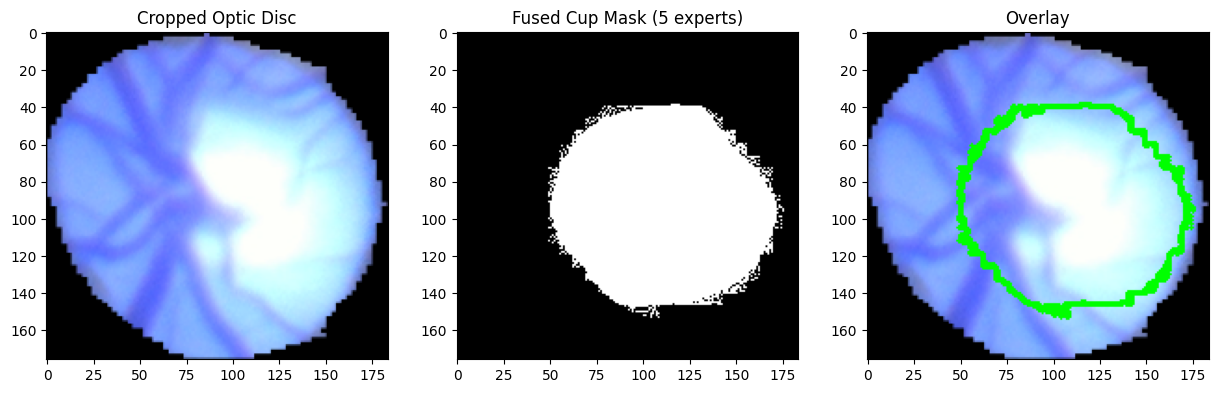

In [11]:
test_image = '/kaggle/input/datasets/mrunal0501/chakshu/Test/1.0_Original_Fundus_Images/Bosch/P10_Image2.JPG'

# Load all 5 expert masks
expert_masks = []
for expert in ['Expert 1', 'Expert 2', 'Expert 3', 'Expert 4', 'Expert 5']:
    mask_path = f'/kaggle/input/datasets/mrunal0501/chakshu/Test/4.0_OD_CO_Fusion_Images/{expert}/Bosch/P10_Image2.tif'
    if os.path.exists(mask_path):
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        expert_masks.append(mask)

# Combine by majority voting
combined_sum = np.zeros_like(expert_masks[0], dtype=np.float32)
for mask in expert_masks:
    combined_sum += (mask > 127).astype(np.float32)

final_mask = (combined_sum >= 3).astype(np.uint8) * 255

# Save temp mask and process
temp_path = '/kaggle/working/temp_mask.png'
cv2.imwrite(temp_path, final_mask)

cropped_image, cropped_mask = crop_optic_disc_and_mask(test_image, temp_path)
cropped_mask = 255 - cropped_mask

# Display
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cropped_image)
plt.title('Cropped Optic Disc')
plt.subplot(1, 3, 2)
plt.imshow(cropped_mask, cmap='gray')
plt.title('Fused Cup Mask (5 experts)')
plt.subplot(1, 3, 3)
overlay = cropped_image.copy()
contours, _ = cv2.findContours(cropped_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)
plt.imshow(overlay)
plt.title('Overlay')
plt.show()

**Cell 4: Batch Processing for all images**

In [12]:
INPUT_PATH = '/kaggle/input/datasets/mrunal0501/chakshu/Test'
OUTPUT_PATH = '/kaggle/working/CHAKSHU_Cropped_OD'

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

# Chakshu dataset structure
camera_types = ['Bosch', 'Forus', 'Remidio']
images_base = os.path.join(INPUT_PATH, '1.0_Original_Fundus_Images')
masks_base = os.path.join(INPUT_PATH, '4.0_OD_CO_Fusion_Images')

# 5 experts
experts = ['Expert 1', 'Expert 2', 'Expert 3', 'Expert 4', 'Expert 5']

stats = {}

print("="*60)
print("PROCESSING CHAKSHU DATASET - COMBINING 5 EXPERT MASKS PER IMAGE")
print("="*60)

for camera in camera_types:
    images_dir = os.path.join(images_base, camera)
    
    if not os.path.exists(images_dir):
        print(f"⚠ Skipping {camera} - images not found at {images_dir}")
        continue
    
    out_images_dir = os.path.join(OUTPUT_PATH, camera, 'images')
    out_masks_dir = os.path.join(OUTPUT_PATH, camera, 'mask')
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_masks_dir, exist_ok=True)
    
    # Get all images
    image_files = [f for f in os.listdir(images_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'))]
    
    print(f"\n📁 Processing {camera} - {len(image_files)} images")
    
    success = 0
    for img_file in tqdm(image_files):
        try:
            img_name = Path(img_file).stem
            img_path = os.path.join(images_dir, img_file)
            
            # STEP 1: Load masks from all 5 experts for this image
            expert_masks = []
            for expert in experts:
                expert_dir = os.path.join(masks_base, expert, camera)
                
                # Find mask with same name
                for ext in ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']:
                    potential_mask = os.path.join(expert_dir, f"{img_name}{ext}")
                    if os.path.exists(potential_mask):
                        mask = cv2.imread(potential_mask, cv2.IMREAD_GRAYSCALE)
                        if mask is not None:
                            expert_masks.append(mask)
                        break
            
            if len(expert_masks) == 0:
                continue
            
            # STEP 2: Combine masks by majority voting (at least 3 out of 5 experts)
            combined_sum = np.zeros_like(expert_masks[0], dtype=np.float32)
            for mask in expert_masks:
                combined_sum += (mask > 127).astype(np.float32)
            
            # Majority voting: threshold = 3 (at least 3 experts agree)
            final_combined_mask = (combined_sum >= 3).astype(np.uint8) * 255
            
            # STEP 3: Save combined mask temporarily
            temp_mask_path = os.path.join('/kaggle/working', f"temp_{img_name}.png")
            cv2.imwrite(temp_mask_path, final_combined_mask)
            
            # STEP 4: Use sir's function with combined mask
            cropped_image, cropped_mask = crop_optic_disc_and_mask(img_path, temp_mask_path)
            
            # STEP 5: INVERT MASK: Make cup white, background black
            cropped_mask = 255 - cropped_mask
            
            # STEP 6: Save results
            output_img_path = os.path.join(out_images_dir, f"{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_image)
            
            output_mask_path = os.path.join(out_masks_dir, f"{img_name}.png")
            cv2.imwrite(output_mask_path, cropped_mask)
            
            # Clean temp file
            os.remove(temp_mask_path)
            
            success += 1
            
        except Exception as e:
            continue
    
    stats[camera] = success
    print(f"  ✅ {camera}: {success} images")

# Create ZIP
zip_path = '/kaggle/working/CHAKSHU_Processed.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.dirname(OUTPUT_PATH)))

print(f"\n✅ ZIP created: {zip_path}")
print(f"📊 Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

print("\n📁 Output Structure:")
print("  CHAKSHU_Cropped_OD/")
print("    ├── Bosch/")
print("    │   ├── images/ (cropped optic discs)")
print("    │   └── mask/ (fused cup masks from 5 experts)")
print("    ├── Forus/")
print("    │   ├── images/")
print("    │   └── mask/")
print("    └── Remidio/")
print("        ├── images/")
print("        └── mask/")

from IPython.display import FileLink, display
display(FileLink(zip_path))

PROCESSING CHAKSHU DATASET - COMBINING 5 EXPERT MASKS PER IMAGE

📁 Processing Bosch - 41 images


100%|██████████| 41/41 [02:31<00:00,  3.69s/it]


  ✅ Bosch: 41 images

📁 Processing Forus - 31 images


100%|██████████| 31/31 [01:58<00:00,  3.81s/it]


  ✅ Forus: 31 images

📁 Processing Remidio - 264 images


100%|██████████| 264/264 [19:12<00:00,  4.37s/it]


  ✅ Remidio: 264 images

✅ ZIP created: /kaggle/working/CHAKSHU_Processed.zip
📊 Size: 4.05 MB

📁 Output Structure:
  CHAKSHU_Cropped_OD/
    ├── Bosch/
    │   ├── images/ (cropped optic discs)
    │   └── mask/ (fused cup masks from 5 experts)
    ├── Forus/
    │   ├── images/
    │   └── mask/
    └── Remidio/
        ├── images/
        └── mask/


/kaggle/working/CHAKSHU_Processed.zip

**Cell 1: Import Libraries**

**Cell 3: Combine 5 Expert Masks into One Final Mask**

In [8]:
def combine_expert_masks(image_name, camera, experts, base_path):
    """
    Combine 5 expert masks using intersection (all experts must agree)
    Returns final combined mask
    """
    expert_masks = []
    
    for expert in experts:
        mask_path = os.path.join(base_path, '4.0_OD_CO_Fusion_Images', expert, camera, f"{image_name}.tif")
        
        # Try different extensions if .tif not found
        if not os.path.exists(mask_path):
            for ext in ['.jpg', '.png', '.bmp']:
                alt_path = os.path.join(base_path, '4.0_OD_CO_Fusion_Images', expert, camera, f"{image_name}{ext}")
                if os.path.exists(alt_path):
                    mask_path = alt_path
                    break
        
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                # Binarize: values > 0 become 1
                binary_mask = (mask > 0).astype(np.uint8)
                expert_masks.append(binary_mask)
    
    if len(expert_masks) != 5:
        return None
    
    # INTERSECTION: pixel = 1 ONLY if ALL 5 masks have 1
    final_mask = np.ones_like(expert_masks[0], dtype=np.uint8)
    for mask in expert_masks:
        final_mask = np.logical_and(final_mask, mask).astype(np.uint8)
    
    # Convert to 0-255 for saving
    final_mask_255 = final_mask * 255
    
    # Save to temp location
    temp_mask_path = '/tmp/combined_mask.png'
    cv2.imwrite(temp_mask_path, final_mask_255)
    
    return temp_mask_path

**Cell 4: Test on Single Image**

In [10]:
test_camera = 'Bosch'
test_image_name = 'P10_Image2'
test_image_path = os.path.join(INPUT_PATH, '1.0_Original_Fundus_Images', test_camera, f"{test_image_name}.JPG")

# Combine 5 expert masks
experts = ['Expert 1', 'Expert 2', 'Expert 3', 'Expert 4', 'Expert 5']
combined_mask_path = combine_expert_masks(test_image_name, test_camera, experts, INPUT_PATH)

if combined_mask_path and os.path.exists(test_image_path):
    # Use the same pipeline as REFUGE2
    cropped_image, cropped_mask = crop_optic_disc_and_mask(test_image_path, combined_mask_path)
    
    # Convert RGB to BGR for saving
    cropped_image_bgr = cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR)
    
    # Display results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(cropped_image)
    axes[0].set_title('Cropped Optic Disc')
    axes[0].axis('off')
    
    axes[1].imshow(cropped_mask, cmap='gray')
    axes[1].set_title('Cropped Mask (Intersection of 5 Experts)')
    axes[1].axis('off')
    
    overlay = cropped_image.copy()
    contours, _ = cv2.findContours(cropped_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (0, 255, 0), 2)
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Cropped Image shape: {cropped_image.shape}")
    print(f"Cropped Mask shape: {cropped_mask.shape}")
    print(f"Mask unique values: {np.unique(cropped_mask)}")
    print(f"Cup area: {np.sum(cropped_mask > 0)} pixels")
    
    # Clean up temp file
    os.remove(combined_mask_path)
else:
    print("Failed to process image")

TypeError: 'NoneType' object is not subscriptable

**Cell 5: Batch Processing for All Chakshu Images**

In [ ]:
# Batch process all Chakshu images
INPUT_PATH = '/kaggle/input/datasets/mrunal0501/chakshu/Test'
OUTPUT_PATH = '/kaggle/working/CHAKSHU_Cropped'

if os.path.exists(OUTPUT_PATH):
    shutil.rmtree(OUTPUT_PATH)
os.makedirs(OUTPUT_PATH)

# Cameras and experts
cameras = ['Bosch', 'Forus', 'Remidio']
experts = ['Expert 1', 'Expert 2', 'Expert 3', 'Expert 4', 'Expert 5']

stats = {}

print("="*60)
print("PROCESSING CHAKSHU DATASET - COMBINING 5 EXPERT MASKS")
print("="*60)

for camera in cameras:
    images_dir = os.path.join(INPUT_PATH, '1.0_Original_Fundus_Images', camera)
    
    if not os.path.exists(images_dir):
        print(f"⚠ Skipping {camera} - images not found")
        continue
    
    out_images_dir = os.path.join(OUTPUT_PATH, camera, 'images')
    out_masks_dir = os.path.join(OUTPUT_PATH, camera, 'mask')
    os.makedirs(out_images_dir, exist_ok=True)
    os.makedirs(out_masks_dir, exist_ok=True)
    
    # Get all images
    image_files = [f for f in os.listdir(images_dir) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif'))]
    
    print(f"\n📁 Processing {camera} - {len(image_files)} images")
    
    success = 0
    for img_file in tqdm(image_files):
        try:
            img_name = Path(img_file).stem
            img_path = os.path.join(images_dir, img_file)
            
            # Combine 5 expert masks into one
            combined_mask_path = combine_expert_masks(img_name, camera, experts, INPUT_PATH)
            
            if combined_mask_path is None:
                continue
            
            # Use the same pipeline as REFUGE2
            cropped_image, cropped_mask = crop_optic_disc_and_mask(img_path, combined_mask_path)
            
            # Save cropped image (already in BGR)
            output_img_path = os.path.join(out_images_dir, f"{img_name}.jpg")
            cv2.imwrite(output_img_path, cropped_image)
            
            # Save cropped mask
            output_mask_path = os.path.join(out_masks_dir, f"{img_name}.png")
            cv2.imwrite(output_mask_path, cropped_mask)
            
            # Clean up temp file
            os.remove(combined_mask_path)
            
            success += 1
            
        except Exception as e:
            continue
    
    stats[camera] = success
    print(f"  ✅ {camera}: {success} images")

# Create ZIP
zip_path = '/kaggle/working/CHAKSHU_Processed.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(OUTPUT_PATH):
        for file in files:
            zipf.write(os.path.join(root, file), os.path.relpath(os.path.join(root, file), os.path.dirname(OUTPUT_PATH)))

print(f"\n✅ ZIP created: {zip_path}")
print(f"📊 Size: {os.path.getsize(zip_path) / (1024**2):.2f} MB")

print("\n📁 Output Structure:")
print("  CHAKSHU_Cropped/")
print("    ├── Bosch/")
print("    │   ├── images/ (cropped optic discs)")
print("    │   └── mask/ (combined masks from 5 experts)")
print("    ├── Forus/")
print("    │   ├── images/")
print("    │   └── mask/")
print("    └── Remidio/")
print("        ├── images/")
print("        └── mask/")

from IPython.display import FileLink, display
display(FileLink(zip_path))

# Print summary
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
for camera, count in stats.items():
    print(f"  ✅ {camera}: {count} images processed")
print(f"\nTotal: {sum(stats.values())} images")